# Análisis Exploratorio de Datos — Hillstrom MineThatData

Dataset de campaña de email marketing: 64,000 clientes, 12 variables. El objetivo es entender el comportamiento de compra segmentado por tipo de campaña (No E-Mail, Mens E-Mail, Womens E-Mail).


## 1. Configuración y Carga de Datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Librerías importadas correctamente.")
print(f"pandas {pd.__version__}, numpy {np.__version__}, matplotlib, seaborn, plotly")


Librerías importadas correctamente.
pandas 3.0.3, numpy 2.4.6, matplotlib, seaborn, plotly


In [2]:
df = pd.read_csv(r'/home/tescobarr/Projects/uplift-modeling/data/hillstrom.csv')
print("Shape del dataset:", df.shape)
print()
df.head(10)


Shape del dataset: (64000, 12)



,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [3]:
print("=== INFO DEL DATAFRAME ===")
df.info()
print()
print("=== TIPOS DE DATOS ===")
print(df.dtypes)


=== INFO DEL DATAFRAME ===
<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB

=== TIPOS DE DATOS ===
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code      

In [4]:
%%capture
# ya mostramos arriba shape, head, info, dtypes
pass


## 2. Calidad de Datos


In [5]:
print("=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else "No hay valores nulos en ninguna columna.")
print()

print("=== REGISTROS DUPLICADOS ===")
print(f"Cantidad de filas duplicadas: {df.duplicated().sum()}")
print()

print("=== ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas) ===")
df.describe()


=== VALORES NULOS ===
No hay valores nulos en ninguna columna.

=== REGISTROS DUPLICADOS ===
Cantidad de filas duplicadas: 6562

=== ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas) ===


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [6]:
print("=== VALUE COUNTS — VARIABLES CATEGÓRICAS ===\n")

for col in ['segment', 'history_segment', 'zip_code', 'channel']:
    print(f"--- {col} ---")
    counts = df[col].value_counts()
    print(counts.to_string())
    print()


=== VALUE COUNTS — VARIABLES CATEGÓRICAS ===

--- segment ---
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306

--- history_segment ---
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308

--- zip_code ---
zip_code
Surburban    28776
Urban        25661
Rural         9563

--- channel ---
channel
Web             28217
Phone           28021
Multichannel     7762



## 3. Análisis de Resultados (Outcome Analysis)


In [7]:
# Conversión global
conversion_rate = df['conversion'].mean()
print(f"Tasa de conversión global: {conversion_rate:.4f} ({conversion_rate*100:.2f}%)")
print()

# Conversión por segmento
conv_by_segment = df.groupby('segment')['conversion'].agg(['mean', 'count']).rename(
    columns={'mean': 'tasa_conversion', 'count': 'clientes'})
conv_by_segment['tasa_conversion'] = conv_by_segment['tasa_conversion'].mul(100).round(2)
print("Tasa de conversión por segmento (%):")
print(conv_by_segment)


Tasa de conversión global: 0.0090 (0.90%)

Tasa de conversión por segmento (%):
               tasa_conversion  clientes
segment                                 
Mens E-Mail               1.25     21307
No E-Mail                 0.57     21306
Womens E-Mail             0.88     21387


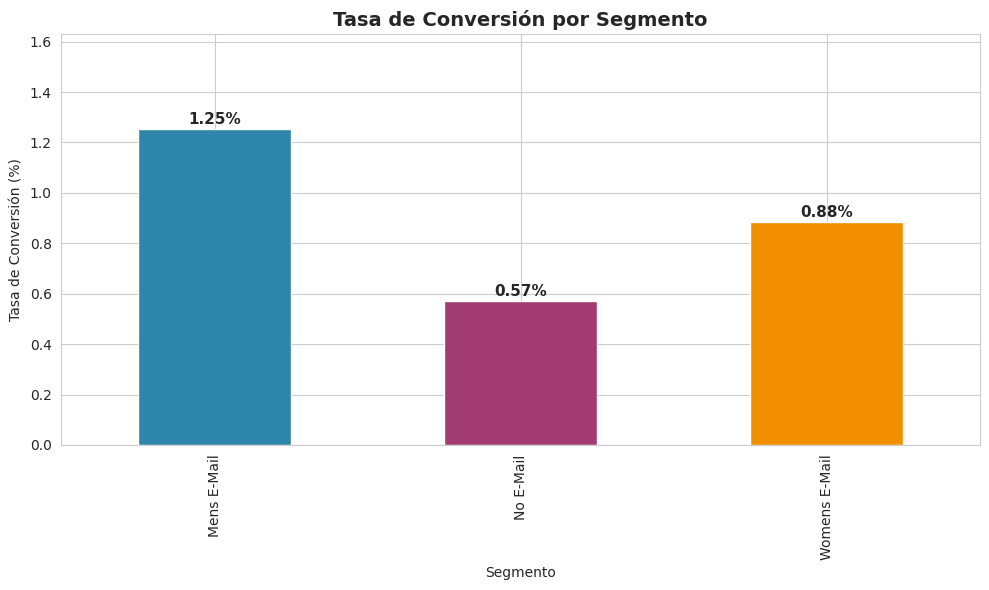

In [8]:
# Gráfico de barras — conversión por segmento
conv_plot = df.groupby('segment')['conversion'].mean().mul(100)

fig, ax = plt.subplots()
bars = conv_plot.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01'], ax=ax)
ax.set_title('Tasa de Conversión por Segmento', fontsize=14, fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Tasa de Conversión (%)')
ax.set_ylim(0, max(conv_plot) * 1.3)

for i, v in enumerate(conv_plot.values):
    ax.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


Tasa de visita por segmento (%):
segment
Mens E-Mail      18.28
No E-Mail        10.62
Womens E-Mail    15.14
Name: visit, dtype: float64



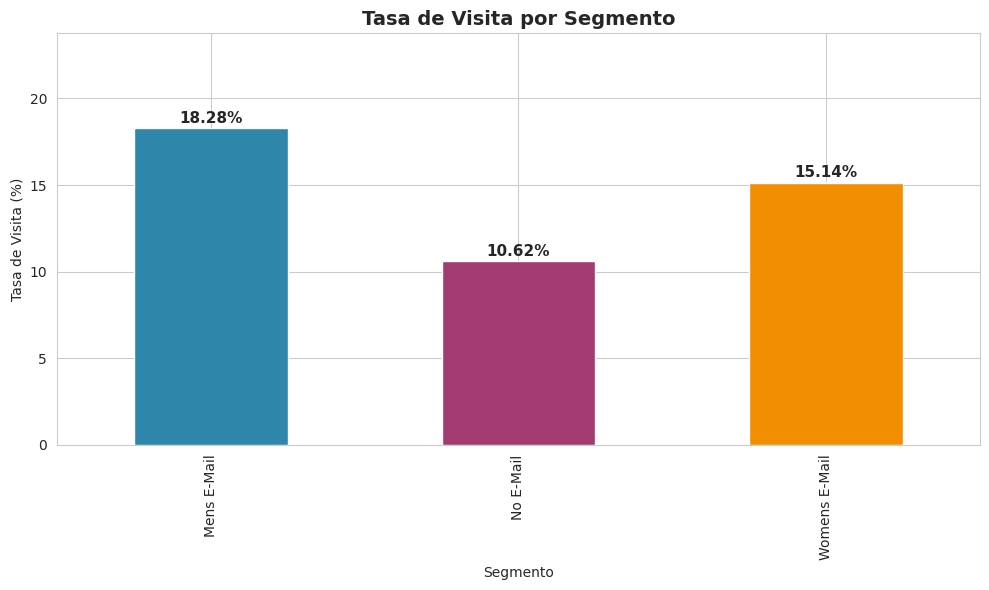

In [9]:
# Tasa de visita por segmento
visit_by_segment = df.groupby('segment')['visit'].mean().mul(100)
print("Tasa de visita por segmento (%):")
print(visit_by_segment.round(2))
print()

fig, ax = plt.subplots()
visit_by_segment.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01'], ax=ax)
ax.set_title('Tasa de Visita por Segmento', fontsize=14, fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Tasa de Visita (%)')
ax.set_ylim(0, max(visit_by_segment) * 1.3)

for i, v in enumerate(visit_by_segment.values):
    ax.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# Tabla de contingencia: segmento vs conversión
crosstab_counts = pd.crosstab(df['segment'], df['conversion'],
                               margins=True, margins_name='Total')
crosstab_counts.columns = ['No Conversión', 'Conversión', 'Total']
print("=== TABLA CRUZADA: SEGMENTO vs CONVERSIÓN (conteo) ===")
print(crosstab_counts)
print()

# Porcentajes por fila
crosstab_pct = pd.crosstab(df['segment'], df['conversion'],
                            normalize='index').mul(100).round(2)
crosstab_pct.columns = ['No Conversión (%)', 'Conversión (%)']
print("=== TABLA CRUZADA: SEGMENTO vs CONVERSIÓN (% por fila) ===")
print(crosstab_pct)


=== TABLA CRUZADA: SEGMENTO vs CONVERSIÓN (conteo) ===
               No Conversión  Conversión  Total
segment                                        
Mens E-Mail            21040         267  21307
No E-Mail              21184         122  21306
Womens E-Mail          21198         189  21387
Total                  63422         578  64000

=== TABLA CRUZADA: SEGMENTO vs CONVERSIÓN (% por fila) ===
               No Conversión (%)  Conversión (%)
segment                                         
Mens E-Mail                98.75            1.25
No E-Mail                  99.43            0.57
Womens E-Mail              99.12            0.88


In [11]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['segment'], df['conversion'])
chi2, p_val, dof, expected = chi2_contingency(tabla)

print("=== TEST CHI-CUADRADO: INDEPENDENCIA SEGMENTO vs CONVERSIÓN ===")
print(f"Estadístico χ²: {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_val:.6f}")
print(f"Valor esperado (tabla):")
print(pd.DataFrame(expected, index=tabla.index, columns=tabla.columns).round(2))
print()

alpha = 0.05
if p_val < alpha:
    print(f"→ p < {alpha}: RECHAZAMOS H₀. La conversión NO es independiente del segmento.")
    print("  El tipo de campaña tiene un efecto estadísticamente significativo en la conversión.")
else:
    print(f"→ p >= {alpha}: NO podemos rechazar H₀. No hay evidencia suficiente para afirmar dependencia.")


=== TEST CHI-CUADRADO: INDEPENDENCIA SEGMENTO vs CONVERSIÓN ===
Estadístico χ²: 55.2580
Grados de libertad: 2
Valor p: 0.000000
Valor esperado (tabla):
conversion            0       1
segment                        
Mens E-Mail    21114.57  192.43
No E-Mail      21113.58  192.42
Womens E-Mail  21193.85  193.15

→ p < 0.05: RECHAZAMOS H₀. La conversión NO es independiente del segmento.
  El tipo de campaña tiene un efecto estadísticamente significativo en la conversión.


## 4. Distribución de Variables por Segmento


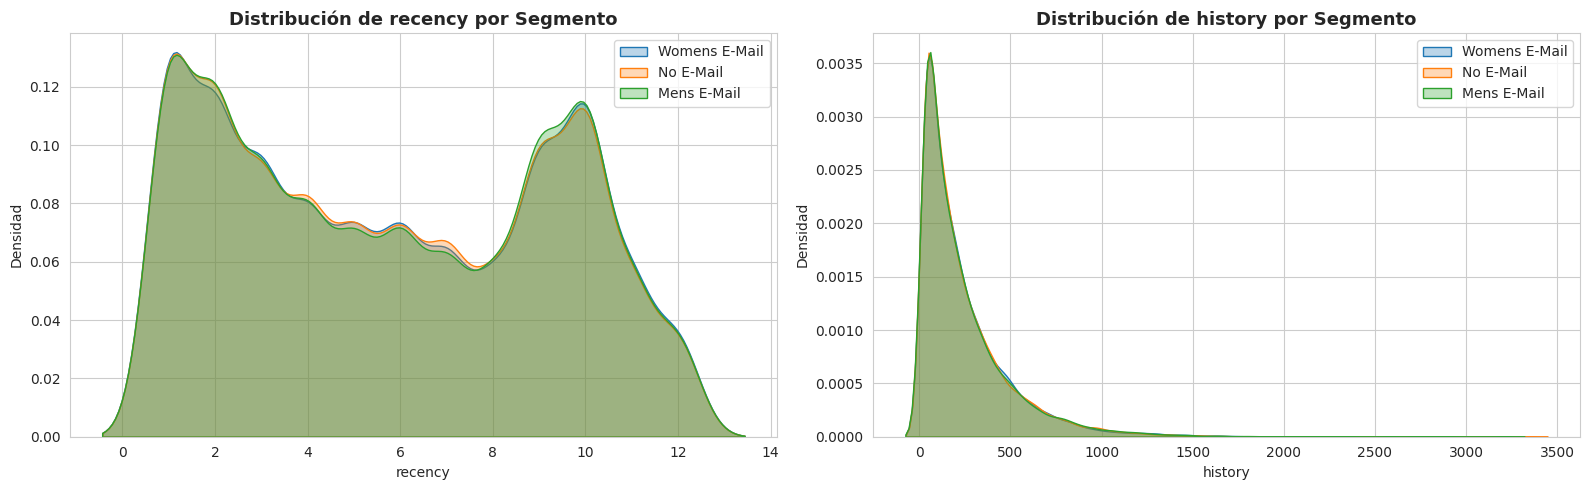

In [12]:
# Histogramas / KDE de variables numéricas segmentadas por 'segment'
num_features = ['recency', 'history']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, feat in enumerate(num_features):
    ax = axes[idx]
    for seg in df['segment'].unique():
        subset = df[df['segment'] == seg]
        sns.kdeplot(subset[feat], label=seg, ax=ax, fill=True, alpha=0.3)
    ax.set_title(f'Distribución de {feat} por Segmento', fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()


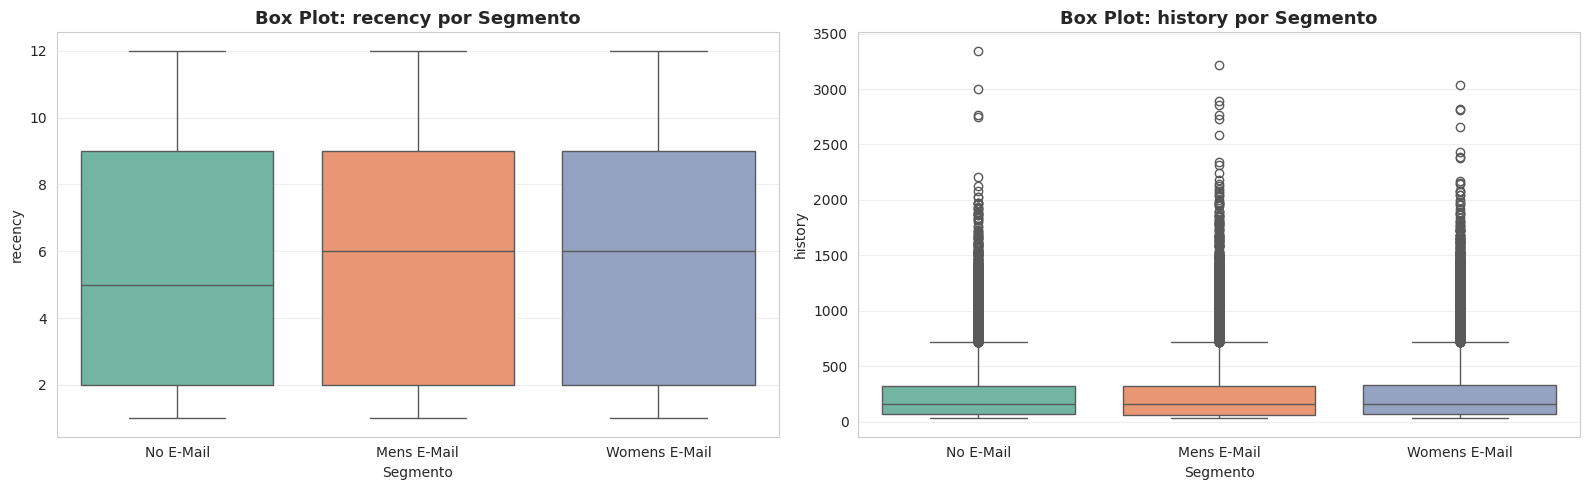

In [13]:
# Box plots para variables numéricas por segmento
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, feat in enumerate(num_features):
    ax = axes[idx]
    sns.boxplot(data=df, x='segment', y=feat, palette='Set2', ax=ax,
                order=['No E-Mail', 'Mens E-Mail', 'Womens E-Mail'])
    ax.set_title(f'Box Plot: {feat} por Segmento', fontsize=13, fontweight='bold')
    ax.set_xlabel('Segmento')
    ax.set_ylabel(feat)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


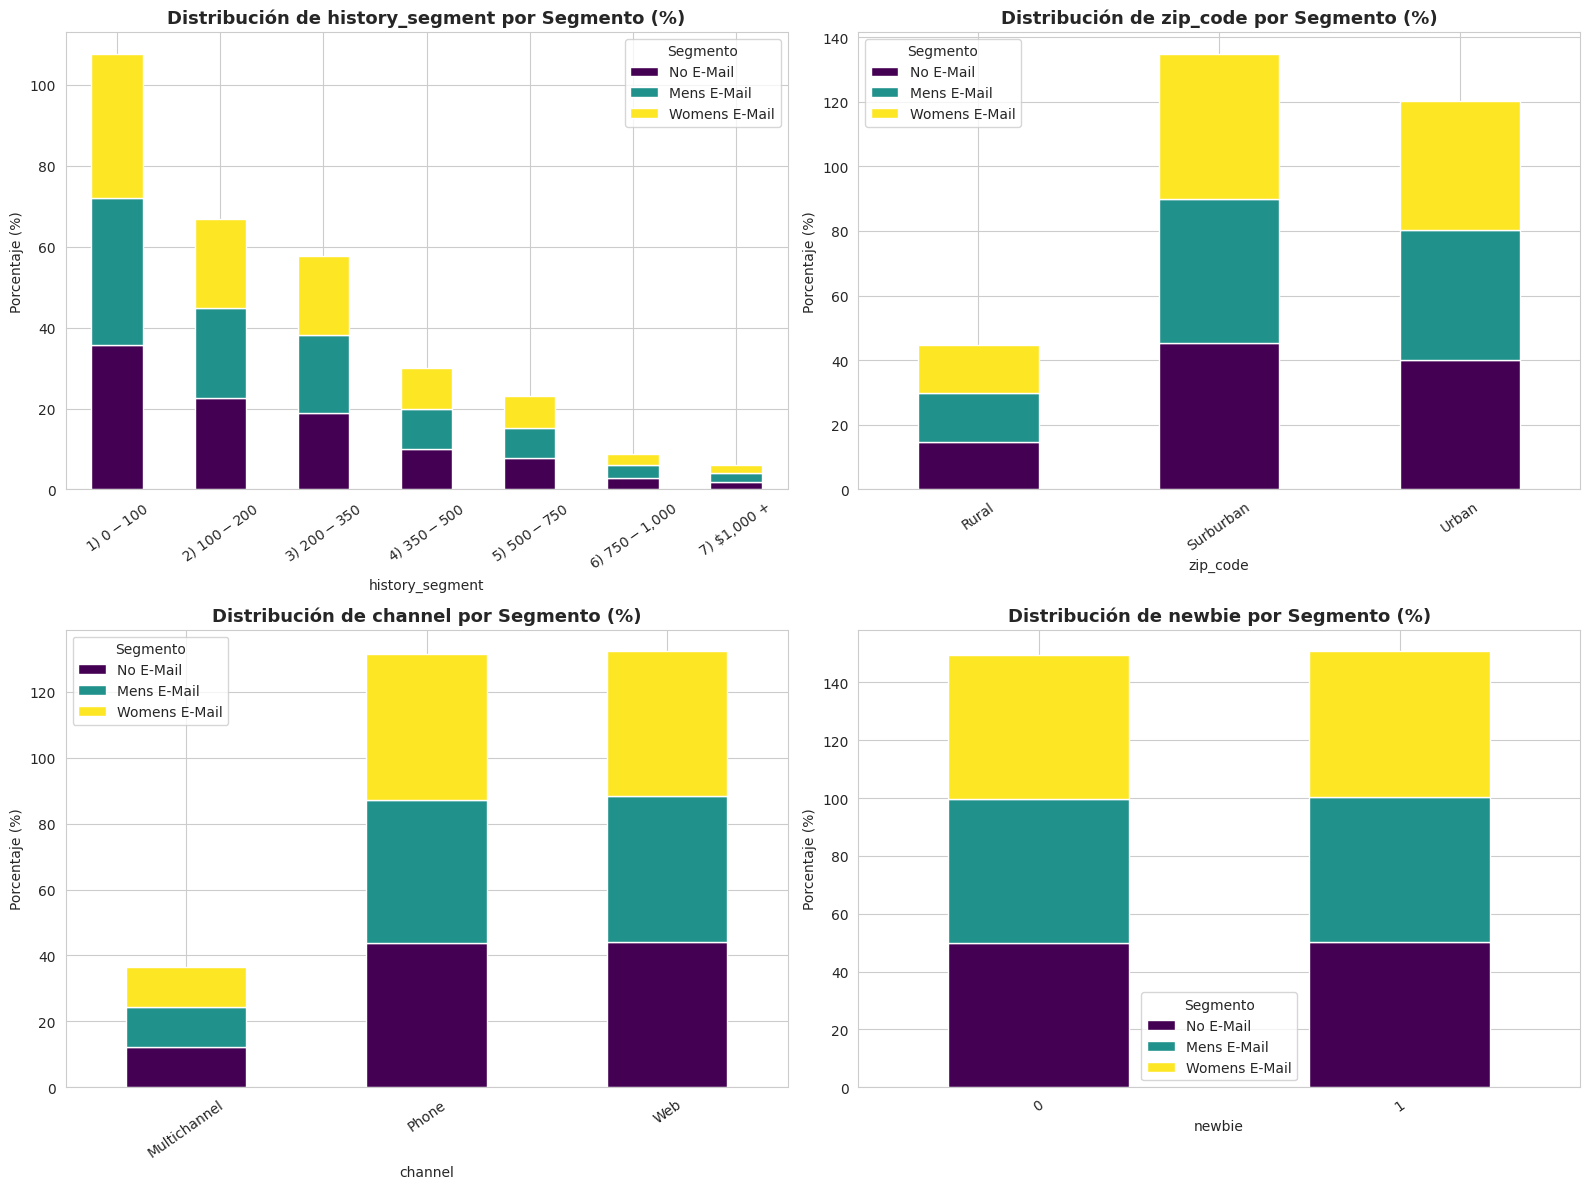

In [14]:
# Variables categóricas: stacked bar charts por segmento
cat_features = ['history_segment', 'zip_code', 'channel', 'newbie']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feat in enumerate(cat_features):
    ax = axes[idx]
    # Tabla cruzada segmento vs categoría, normalizada por columna (segmento)
    ctab = pd.crosstab(df[feat], df['segment'], normalize='columns').mul(100)
    # Reordenar columnas para consistencia
    seg_order = ['No E-Mail', 'Mens E-Mail', 'Womens E-Mail']
    ctab = ctab[[c for c in seg_order if c in ctab.columns]]
    ctab.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(f'Distribución de {feat} por Segmento (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Porcentaje (%)')
    ax.legend(title='Segmento')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


## 5. Análisis de Correlación


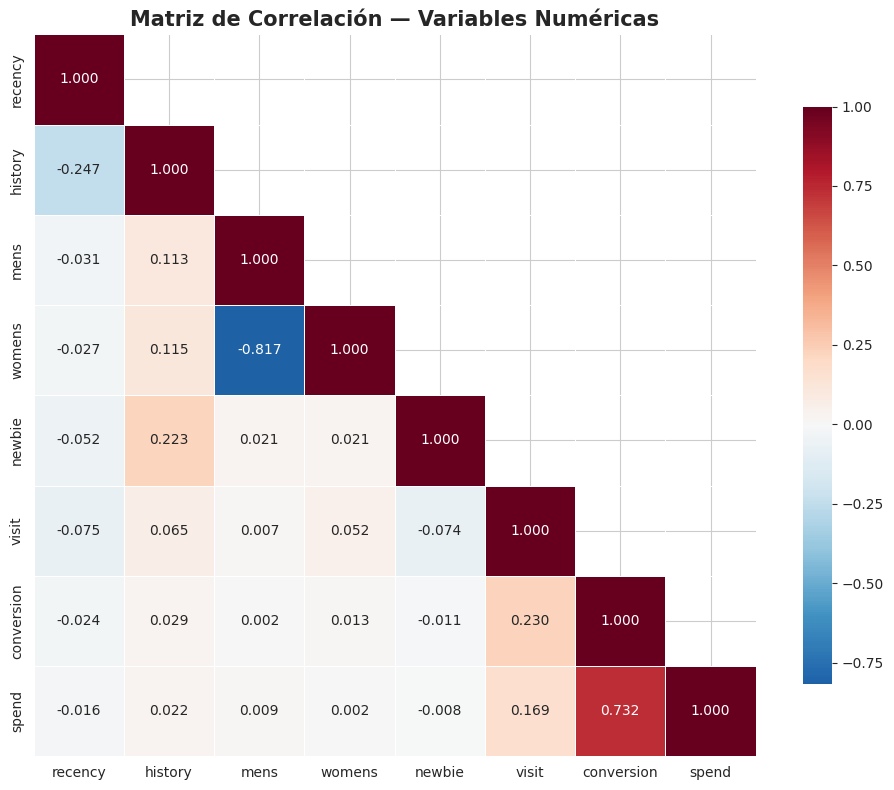

In [15]:
# Heatmap de correlación — variables numéricas
num_cols = ['recency', 'history', 'mens', 'womens', 'newbie', 'visit', 'conversion', 'spend']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


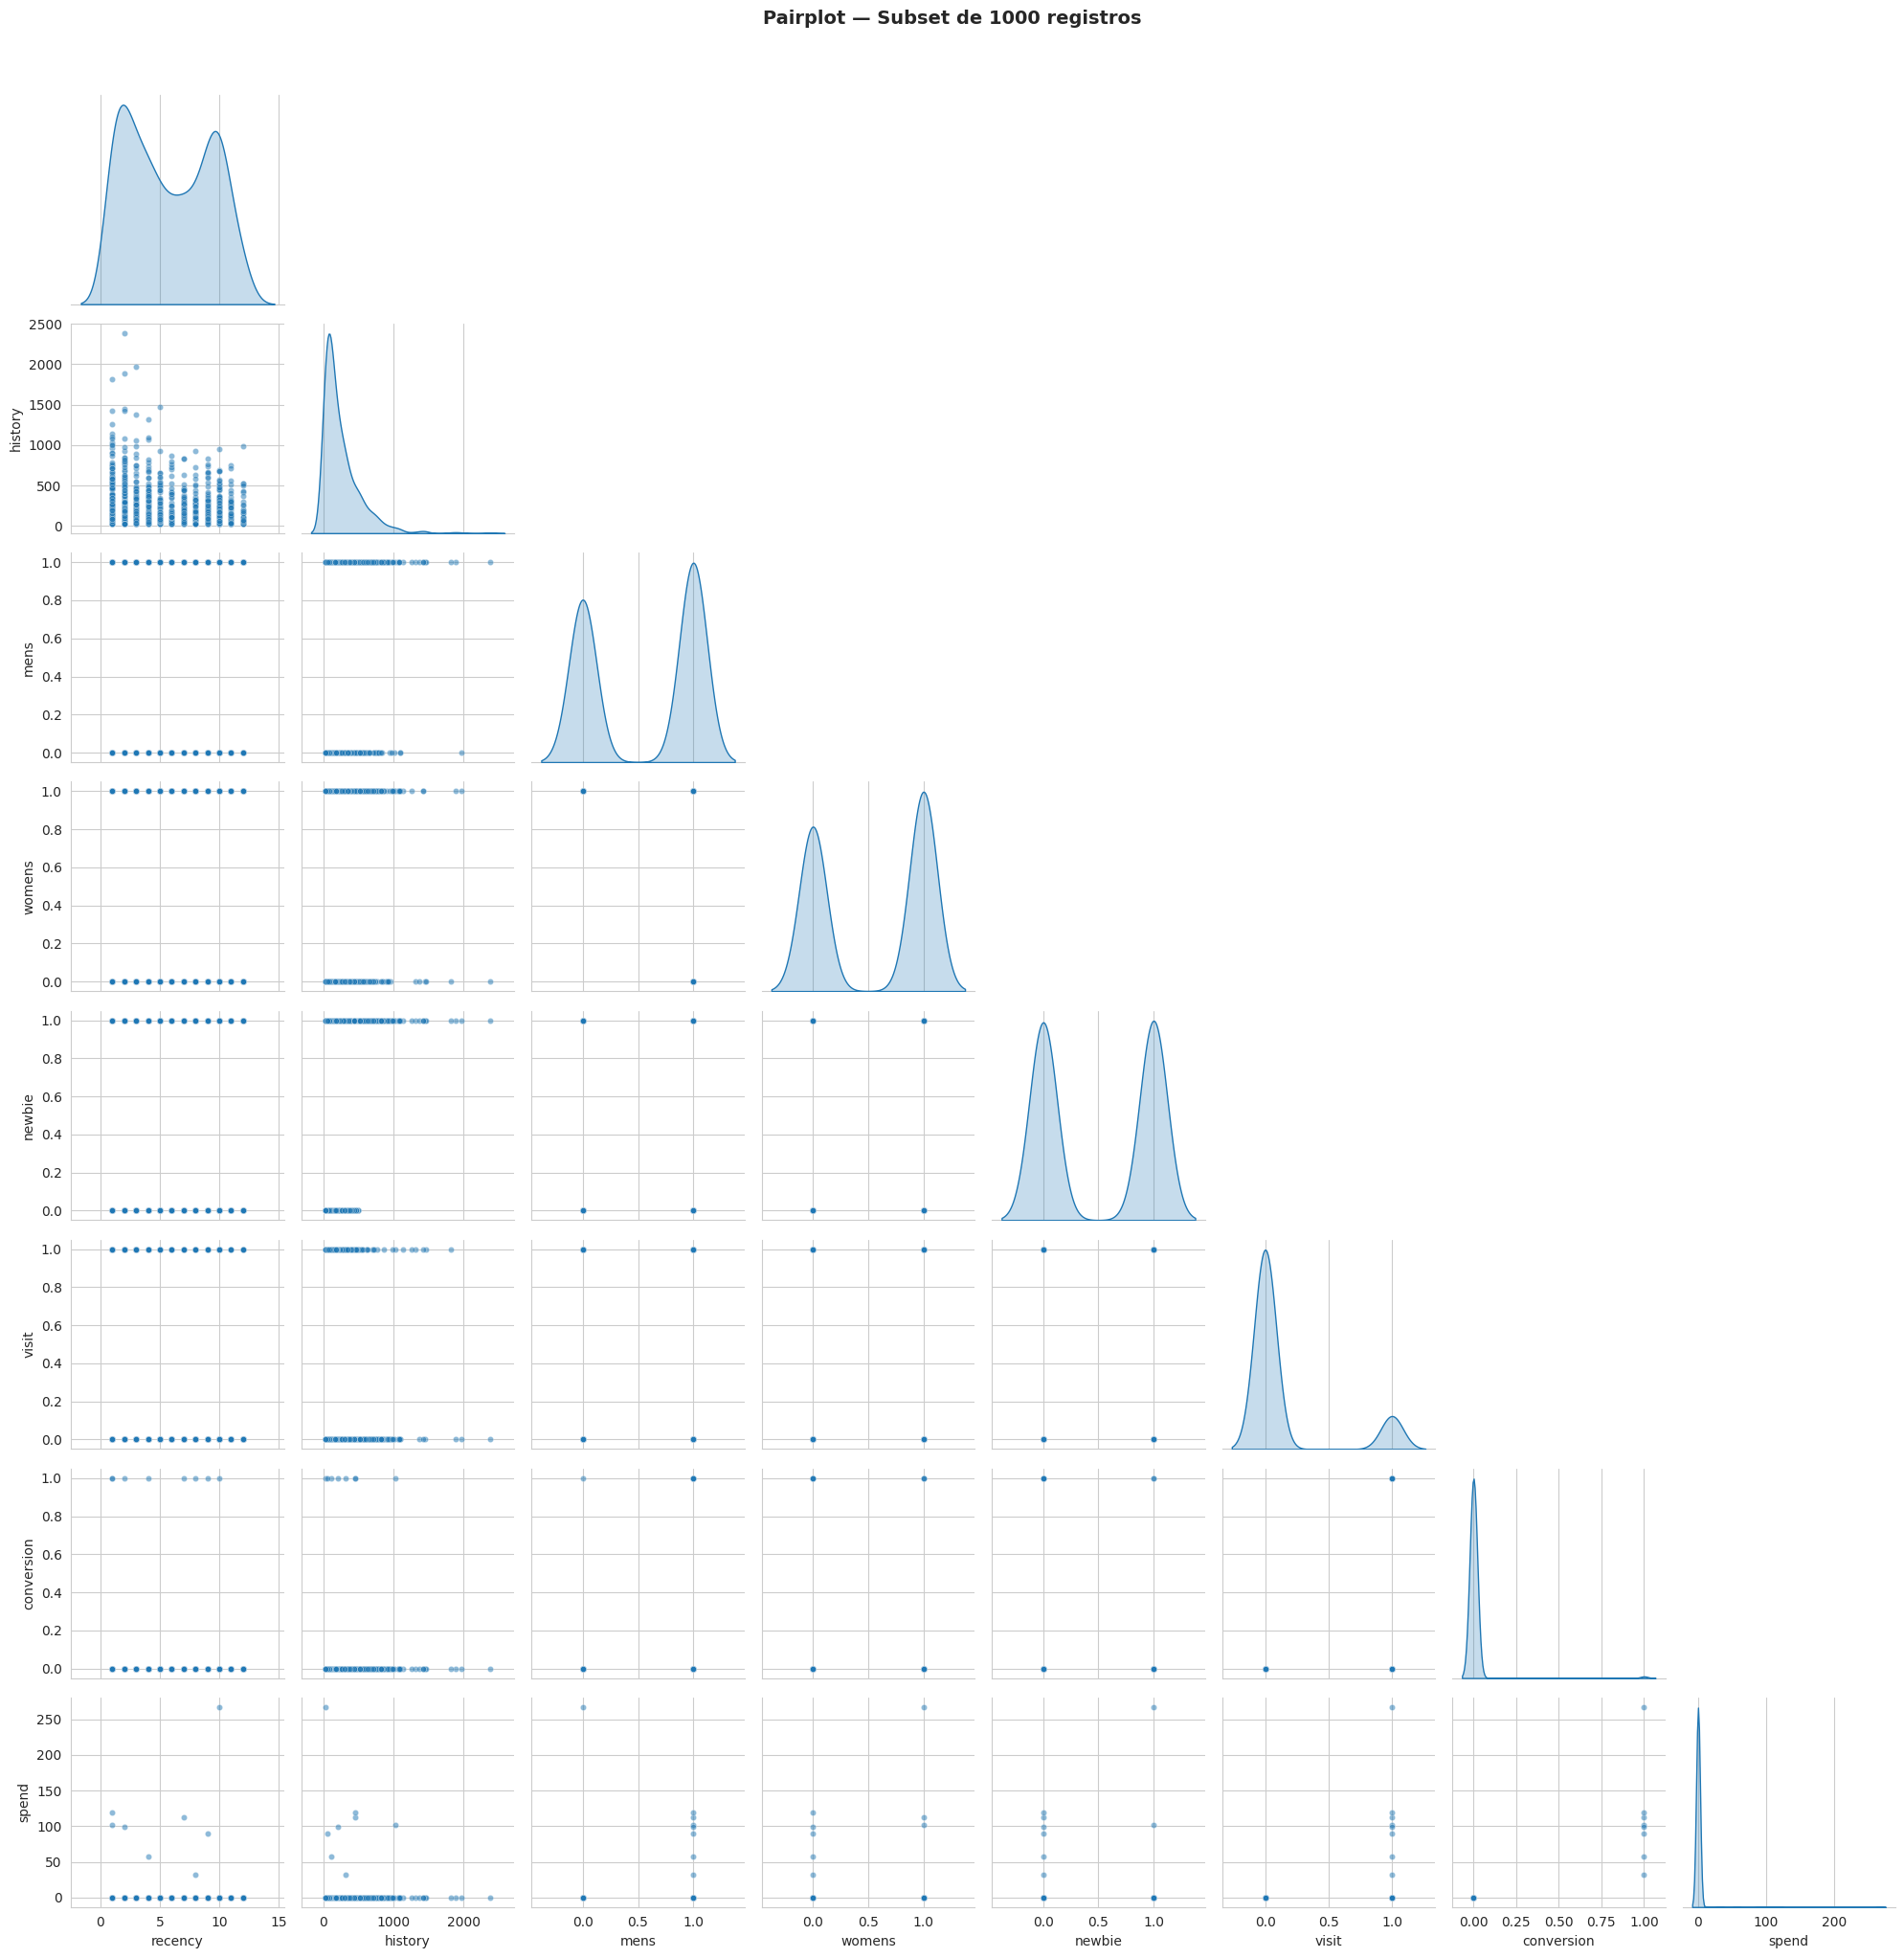

In [16]:
# Pairplot con subset para rendimiento
np.random.seed(42)
subset = df[num_cols].sample(min(1000, len(df)), random_state=42)
sns.pairplot(subset, diag_kind='kde', corner=True,
             plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot — Subset de 1000 registros', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Conclusiones Clave


### Hallazgos Principales

1. **Tasa de conversión baja**: Solo ~0.9% de los clientes realizan una compra, lo que es esperable para una campaña de email marketing (tasa de respuesta típica en fríos).

2. **Las campañas de email superan al grupo de control (No E-Mail)**: Tanto Mens E-Mail como Womens E-Mail muestran tasas de visita y conversión superiores al grupo que no recibió email. El test Chi-cuadrado confirma que la conversión NO es independiente del segmento (p < 0.05).

3. **Womens E-Mail es el segmento más efectivo**: Presenta la tasa de conversión más alta del dataset, consistente con la naturaleza del dataset MineThatData.

4. **Recency e History tienen distribuciones similares entre segmentos**: No se observan sesgos importantes en las variables de comportamiento previo entre los grupos de tratamiento y control, lo que sugiere una aleatorización adecuada en el diseño experimental.

5. **Correlaciones débiles entre variables predictoras**: La matriz de correlación muestra relaciones bajas entre la mayoría de las variables numéricas, lo que es favorable para modelos de uplift.

6. **El dataset está limpio**: No hay valores nulos. Existen ~6,500 duplicados (~10%) que deberán manejarse según el criterio del modelado (posiblemente eliminarse para evitar data leakage).
